## Imports

In [3]:
import sys
sys.path.append("../src")

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
import os
import math
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

In [5]:
# Path to BIDMC PhysioNet dataset
data_dir = Path(
    r"G:\1-1- Articles\1- Hybrid_Quantum_STATE_PREPRATION_VIA_DATA_COMPRESSION\Datasets\bidmc-ppg-and-respiration-dataset-1.0.0\bidmc_csv"
)

signal_files = sorted(
    data_dir.glob("*_Signals.csv")
)

print(f"Found {len(signal_files)} files")

Found 53 files


In [6]:
for f in signal_files[:5]:
    print(f.name)

bidmc_01_Signals.csv
bidmc_02_Signals.csv
bidmc_03_Signals.csv
bidmc_04_Signals.csv
bidmc_05_Signals.csv


In [7]:
lengths = []

for file in signal_files:

    df = pd.read_csv(file)

    df.columns = df.columns.str.strip()

    ppg = df["PLETH"].astype(float).values

    lengths.append(len(ppg))

print("Signals:", len(lengths))
print("Min length:", min(lengths))
print("Max length:", max(lengths))
print("Mean length:", np.mean(lengths))

Signals: 53
Min length: 60001
Max length: 60001
Mean length: 60001.0


In [8]:
def load_ppg_signal(file_path):
    """
    Load a PPG waveform, zero-pad it to the next
    power of two, and normalize it.
    """

    df = pd.read_csv(file_path)

    df.columns = df.columns.str.strip()

    signal = df["PLETH"].astype(float).values

    # Zero-padding
    N_orig = len(signal)

    next_pow2 = 2 ** math.ceil(
        math.log2(N_orig)
    )

    pad_len = next_pow2 - N_orig

    signal = np.pad(
        signal,
        (0, pad_len),
        mode="constant"
    )

    # Normalization
    signal = (
        signal /
        np.linalg.norm(signal)
    )

    return signal

In [9]:
signal = load_ppg_signal(
    signal_files[0]
)

print(signal.shape)
print(np.linalg.norm(signal))

(65536,)
0.9999999999999993


In [10]:
sizes = []

for file in signal_files:

    signal = load_ppg_signal(file)

    sizes.append(len(signal))

print(np.unique(sizes))

[65536]


In [11]:
signal = load_ppg_signal(
    signal_files[0]
)

print(signal.shape)

(65536,)


In [12]:
level = 13

X = haar_packet_transform(
    signal,
    level
)

print(X.shape)

(65536,)


In [13]:
k = 3000

X_top = top_k_threshold(
    X,
    k
)

print(
    np.count_nonzero(X_top)
)

3000


In [14]:
X_norm = (
    X_top /
    np.linalg.norm(X_top)
)

In [15]:
print(
    np.linalg.norm(X_norm)
)

0.9999999999999999


In [16]:
signal_rec = inverse_haar_packet_transform(
    X_norm,
    level
)

In [17]:
td = trace_distance(
    signal,
    signal_rec
)

print(td)

0.039337767716098516


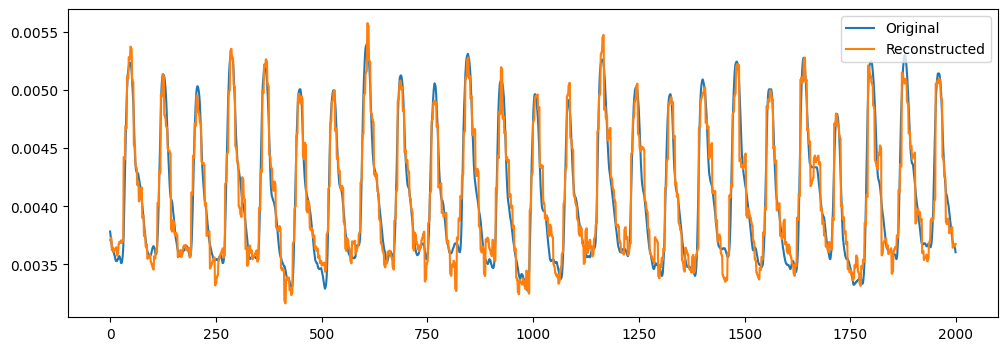

In [18]:
plt.figure(figsize=(12,4))

plt.plot(
    signal[:2000],
    label="Original"
)

plt.plot(
    signal_rec[:2000],
    label="Reconstructed"
)

plt.legend()
plt.show()

## k=3000

In [19]:
k = 3000

levels = range(1, 16)

td_values = []

for level in levels:

    X = haar_packet_transform(
        signal,
        level
    )

    X_top = top_k_threshold(
        X,
        k
    )

    X_norm = (
        X_top /
        np.linalg.norm(X_top)
    )

    signal_rec = inverse_haar_packet_transform(
        X_norm,
        level
    )

    td = trace_distance(
        signal,
        signal_rec
    )

    td_values.append(td)

    print(
        f"L={level:2d} | TD={td:.6f}"
    )

L= 1 | TD=0.917060
L= 2 | TD=0.837884
L= 3 | TD=0.695269
L= 4 | TD=0.386499
L= 5 | TD=0.055570
L= 6 | TD=0.057222
L= 7 | TD=0.052502
L= 8 | TD=0.046319
L= 9 | TD=0.043412
L=10 | TD=0.041728
L=11 | TD=0.039037
L=12 | TD=0.037968
L=13 | TD=0.039338
L=14 | TD=0.039266
L=15 | TD=0.040391


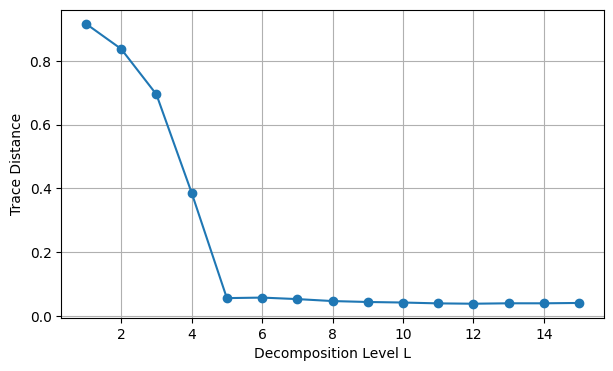

In [20]:
plt.figure(figsize=(7,4))

plt.plot(
    levels,
    td_values,
    "o-"
)

plt.xlabel("Decomposition Level L")
plt.ylabel("Trace Distance")
plt.grid(True)

plt.show()

In [21]:
best_idx = np.argmin(td_values)

best_level = list(levels)[best_idx]

best_td = td_values[best_idx]

print(
    f"Best level = {best_level}"
)

print(
    f"Best TD = {best_td:.6f}"
)

Best level = 12
Best TD = 0.037968


In [22]:
import pandas as pd

k = 3000

levels = range(1, 16)

results = []

for signal_idx, file in enumerate(signal_files, start=1):

    signal = load_ppg_signal(file)

    td_values = []

    for level in levels:

        X = haar_packet_transform(
            signal,
            level
        )

        X_top = top_k_threshold(
            X,
            k
        )

        X_norm = (
            X_top /
            np.linalg.norm(X_top)
        )

        signal_rec = inverse_haar_packet_transform(
            X_norm,
            level
        )

        td = trace_distance(
            signal,
            signal_rec
        )

        td_values.append(td)

    best_idx = np.argmin(td_values)

    best_level = list(levels)[best_idx]

    best_td = td_values[best_idx]

    results.append(
        {
            "Signal": signal_idx,
            "Best Level": best_level,
            "Best TD": best_td,
        }
    )

    print(
        f"Signal {signal_idx:2d}"
        f" | Best L = {best_level}"
        f" | TD = {best_td:.6f}"
    )

Signal  1 | Best L = 12 | TD = 0.037968
Signal  2 | Best L = 11 | TD = 0.079561
Signal  3 | Best L = 12 | TD = 0.088285
Signal  4 | Best L = 12 | TD = 0.090549
Signal  5 | Best L = 13 | TD = 0.044079
Signal  6 | Best L = 15 | TD = 0.097537
Signal  7 | Best L = 15 | TD = 0.074191
Signal  8 | Best L = 14 | TD = 0.085824
Signal  9 | Best L = 12 | TD = 0.069602
Signal 10 | Best L = 12 | TD = 0.085554
Signal 11 | Best L = 12 | TD = 0.059623
Signal 12 | Best L = 12 | TD = 0.045440
Signal 13 | Best L = 15 | TD = 0.061769
Signal 14 | Best L = 12 | TD = 0.072089
Signal 15 | Best L = 12 | TD = 0.066193
Signal 16 | Best L = 12 | TD = 0.076956
Signal 17 | Best L = 10 | TD = 0.095401
Signal 18 | Best L = 14 | TD = 0.066277
Signal 19 | Best L = 12 | TD = 0.014519
Signal 20 | Best L = 11 | TD = 0.032617
Signal 21 | Best L = 11 | TD = 0.044511
Signal 22 | Best L = 11 | TD = 0.040750
Signal 23 | Best L = 12 | TD = 0.089539
Signal 24 | Best L = 10 | TD = 0.058228
Signal 25 | Best L = 12 | TD = 0.044011


In [23]:
results_df = pd.DataFrame(results)

In [24]:
level_counts = (
    results_df["Best Level"]
    .value_counts()
    .sort_index()
)

print(level_counts)

Best Level
10     8
11    11
12    26
13     2
14     2
15     4
Name: count, dtype: int64


In [25]:
print(
    "Mean TD:",
    results_df["Best TD"].mean()
)

print(
    "Std TD:",
    results_df["Best TD"].std()
)

Mean TD: 0.06551405977944202
Std TD: 0.020753378787698132


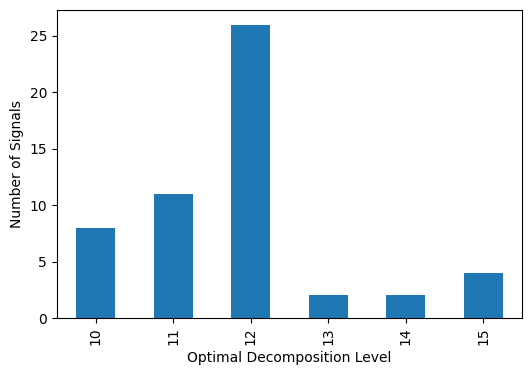

In [26]:
plt.figure(figsize=(6,4))

level_counts.plot(
    kind="bar"
)

plt.xlabel(
    "Optimal Decomposition Level"
)

plt.ylabel(
    "Number of Signals"
)

plt.show()

In [27]:
def analyze_dataset(k):

    levels = range(1, 16)

    results = []

    for signal_idx, file in enumerate(signal_files, start=1):

        signal = load_ppg_signal(file)

        td_values = []

        for level in levels:

            X = haar_packet_transform(
                signal,
                level
            )

            X_top = top_k_threshold(
                X,
                k
            )

            X_norm = (
                X_top /
                np.linalg.norm(X_top)
            )

            signal_rec = (
                inverse_haar_packet_transform(
                    X_norm,
                    level
                )
            )

            td = trace_distance(
                signal,
                signal_rec
            )

            td_values.append(td)

        best_idx = np.argmin(td_values)

        results.append(
            {
                "Signal": signal_idx,
                "Best Level": list(levels)[best_idx],
                "Best TD": td_values[best_idx],
            }
        )

    return pd.DataFrame(results)

In [28]:
results_300 = analyze_dataset(260)

results_1500 = analyze_dataset(1500)

results_3000 = analyze_dataset(3000)

In [29]:
for k, df in [
    (300, results_300),
    (1500, results_1500),
    (3000, results_3000),
]:

    print("\n")
    print(f"k = {k}")

    print(
        df["Best Level"]
        .value_counts()
        .sort_index()
    )

    print(
        "\nMean TD:",
        df["Best TD"].mean()
    )

    print(
        "Std TD:",
        df["Best TD"].std()
    )



k = 300
Best Level
11     8
12    20
13    15
14     7
15     3
Name: count, dtype: int64

Mean TD: 0.17903949853871404
Std TD: 0.05255915688848043


k = 1500
Best Level
10     6
11    10
12    25
13     3
14     4
15     5
Name: count, dtype: int64

Mean TD: 0.100384418034899
Std TD: 0.031111435825615846


k = 3000
Best Level
10     8
11    11
12    26
13     2
14     2
15     4
Name: count, dtype: int64

Mean TD: 0.06551405977944202
Std TD: 0.020753378787698132


In [36]:
results_300["Best Level"].mean(), results_1500["Best Level"].mean(), results_3000["Best Level"].mean()

(np.float64(12.566037735849056),
 np.float64(12.075471698113208),
 np.float64(11.830188679245284))

In [37]:
def analyze_levels(k):

    levels = range(1, 16)

    all_td = []

    for file in signal_files:

        signal = load_ppg_signal(file)

        td_values = []

        for level in levels:

            X = haar_packet_transform(signal, level)

            X_top = top_k_threshold(X, k)

            X_norm = X_top / np.linalg.norm(X_top)

            signal_rec = inverse_haar_packet_transform(
                X_norm,
                level
            )

            td = trace_distance(
                signal,
                signal_rec
            )

            td_values.append(td)

        all_td.append(td_values)

    all_td = np.array(all_td)

    mean_td = all_td.mean(axis=0)
    std_td  = all_td.std(axis=0)

    return mean_td, std_td

In [40]:
mean_td_300, std_td_300 = analyze_levels(260)

mean_td_1500, std_td_1500 = analyze_levels(1500)

mean_td_3000, std_td_3000 = analyze_levels(3000)

KeyboardInterrupt: 

In [ ]:
plt.errorbar(
    levels,
    mean_td_300,
    yerr=std_td_300,
    marker="o",
    label=r"$k=n^2$"    
)

plt.errorbar(
    levels,
    mean_td_1500,
    yerr=std_td_1500,
    marker="s",
    label=r"$k=6n^2$"
)

plt.errorbar(
    levels,
    mean_td_3000,
    yerr=std_td_3000,
    marker="^",
    label=r"$k=12n^2$"
)

# Plot the figure of the paper

In [41]:
levels = range(1, 16)

k_values = [260, 1500, 3000]

mean_td = {}
std_td = {}

for k in k_values:

    mean_td[k] = []
    std_td[k] = []

    print(f"\nProcessing k = {k}")

    for level in levels:

        td_list = []

        for file in signal_files:

            signal = load_ppg_signal(file)

            X = haar_packet_transform(
                signal,
                level
            )

            X_top = top_k_threshold(
                X,
                k
            )

            X_norm = (
                X_top /
                np.linalg.norm(X_top)
            )

            signal_rec = (
                inverse_haar_packet_transform(
                    X_norm,
                    level
                )
            )

            td = trace_distance(
                signal,
                signal_rec
            )

            td_list.append(td)

        mean_td[k].append(
            np.mean(td_list)
        )

        std_td[k].append(
            np.std(td_list)
        )

        print(
            f"L={level:2d} "
            f"Mean TD={np.mean(td_list):.5f}"
        )


Processing k = 260
L= 1 Mean TD=0.98806
L= 2 Mean TD=0.97780
L= 3 Mean TD=0.95874
L= 4 Mean TD=0.92532
L= 5 Mean TD=0.87718
L= 6 Mean TD=0.81297
L= 7 Mean TD=0.64548
L= 8 Mean TD=0.24735
L= 9 Mean TD=0.21807
L=10 Mean TD=0.20171
L=11 Mean TD=0.19140
L=12 Mean TD=0.18705
L=13 Mean TD=0.18712
L=14 Mean TD=0.18884
L=15 Mean TD=0.19260

Processing k = 1500
L= 1 Mean TD=0.94110
L= 2 Mean TD=0.88798
L= 3 Mean TD=0.78976
L= 4 Mean TD=0.63018
L= 5 Mean TD=0.36359
L= 6 Mean TD=0.16354
L= 7 Mean TD=0.13943
L= 8 Mean TD=0.12509
L= 9 Mean TD=0.11487
L=10 Mean TD=0.10776
L=11 Mean TD=0.10324
L=12 Mean TD=0.10147
L=13 Mean TD=0.10366
L=14 Mean TD=0.10472
L=15 Mean TD=0.10603

Processing k = 3000
L= 1 Mean TD=0.88758
L= 2 Mean TD=0.78685
L= 3 Mean TD=0.61538
L= 4 Mean TD=0.31978
L= 5 Mean TD=0.09754
L= 6 Mean TD=0.09646
L= 7 Mean TD=0.08720
L= 8 Mean TD=0.07999
L= 9 Mean TD=0.07411
L=10 Mean TD=0.06978
L=11 Mean TD=0.06725
L=12 Mean TD=0.06628
L=13 Mean TD=0.06835
L=14 Mean TD=0.06906
L=15 Mean TD=0

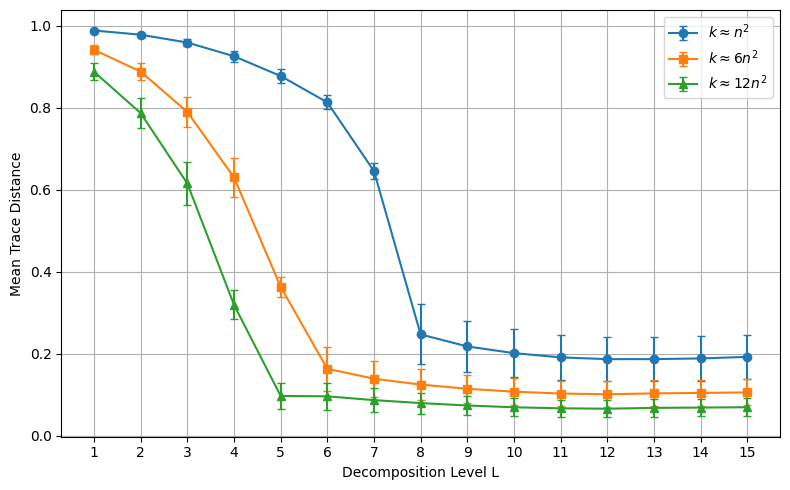

In [43]:
plt.figure(figsize=(8,5))

plt.errorbar(
    levels,
    mean_td[260],
    yerr=std_td[260],
    marker="o",
    capsize=3,
    label=r"$k \approx n^2$"
)

plt.errorbar(
    levels,
    mean_td[1500],
    yerr=std_td[1500],
    marker="s",
    capsize=3,
    label=r"$k \approx 6n^2$"
)

plt.errorbar(
    levels,
    mean_td[3000],
    yerr=std_td[3000],
    marker="^",
    capsize=3,
    label=r"$k\approx 12n^2$"
)

plt.xlabel(
    "Decomposition Level L"
)

plt.ylabel(
    "Mean Trace Distance"
)

plt.xticks(levels)

plt.grid(True)

plt.legend()

plt.tight_layout()
plt.savefig("../figures/PPG_dataset_analysis.pdf")
plt.show()